# Analyse de fusion multimodale par scores out-of-fold

Ce notebook évalue la fusion tardive à partir de scores unimodaux out-of-fold. Chaque score provient donc d'un modèle entraîné sans l'exemple évalué. Les pseudo-patients restent construits par appariement de labels entre datasets différents : l'analyse est méthodologiquement plus propre que l'ancienne version, mais elle ne remplace pas un vrai dataset multimodal par sujet.

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def find_project_root(start: Path) -> Path:
    """Find the repository root from the notebook execution directory."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'src').exists() and (candidate / 'models').exists():
            return candidate
    raise RuntimeError('Impossible de trouver la racine du projet. Lancez le notebook depuis le dépôt.')

ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.fusion_dataset_validation import (
    OOF_SCORES,
    evaluate_configurations,
    load_oof_pools,
    summarize_pool,
)

## 1. Chargement des scores OOF

Le fichier `data/processed/multimodal_oof_scores.csv` est généré par `scripts/generate_unimodal_oof_scores.py`. Si le fichier est absent, il faut d'abord exécuter ce script.

In [10]:
if not OOF_SCORES.exists():
    raise FileNotFoundError(
        f'Scores OOF introuvables : {OOF_SCORES.relative_to(ROOT)}. '
        'Exécutez python scripts/generate_unimodal_oof_scores.py'
    )

oof_scores = pd.read_csv(OOF_SCORES)
display(oof_scores.head())
display(oof_scores.groupby(['modality', 'label']).size().unstack(fill_value=0))

,modality,sample_id,subject_id,label,source_dataset,fold,score
0,drawing,data/spiral/training/healthy/V01HE02.png,V01HE,0,spiral,3.0,0.305952
1,drawing,data/spiral/training/healthy/V01HE03.png,V01HE,0,spiral,3.0,0.242722
2,drawing,data/spiral/training/healthy/V02HE02.png,V02HE,0,spiral,4.0,0.674778
3,drawing,data/spiral/training/healthy/V02HE03.png,V02HE,0,spiral,4.0,0.327167
4,drawing,data/spiral/training/healthy/V03HE2.png,V03HE,0,spiral,3.0,0.219500


label,0,1
modality,,
drawing,51,51
keyboard,55,60
voice,192,564


### Analyse du fichier OOF

Le fichier contient **973 prédictions out-of-fold** réparties sur les trois modalités. Le dessin est équilibré (**51 contrôles / 51 Parkinson**), le clavier est presque équilibré (**55 / 60**), et la voix est nettement déséquilibrée (**192 / 564**). Ce déséquilibre est important : il justifie d'utiliser des métriques comme l'**AUC** et la **balanced accuracy**, plutôt qu'une accuracy simple qui serait trop influencée par la classe majoritaire.

Chaque ligne correspond à un score produit sur un fold de test. Le champ `fold` permet de garder une trace du fold ayant produit la prédiction, et `subject_id` permet de vérifier que les observations d'un même sujet ne sont pas dispersées entre train et test.

## 2. Performance unimodale

Cette table mesure la séparation des scores out-of-fold pour chaque modalité prise seule. Elle est plus représentative que les scores obtenus avec les modèles finaux entraînés sur tout le dataset.

In [11]:
pools = load_oof_pools()
pool_summary = pd.DataFrame(summarize_pool(name, pool) for name, pool in pools.items())
display(pool_summary.round(3))

,configuration,n_hc,n_pd,mean_hc,mean_pd,auc,balanced_accuracy_at_0.5
0,drawing,51,51,0.394,0.584,0.833,0.725
1,keyboard,55,60,0.387,0.691,0.782,0.693
2,voice,192,564,0.395,0.624,0.753,0.670


### Analyse unimodale

Les trois modalités séparent les classes au-dessus du hasard, mais avec des forces différentes. Le **dessin** obtient la meilleure AUC unimodale (**0.833**) et une balanced accuracy de **0.725**. Le **clavier** suit avec une AUC de **0.782** et une balanced accuracy de **0.693**. La **voix** est plus faible mais reste informative, avec une AUC de **0.753** et une balanced accuracy de **0.670**.

Les moyennes de scores vont dans le bon sens pour chaque modalité : les contrôles ont des scores moyens plus bas que les patients Parkinson. La séparation n'est cependant pas parfaite, ce qui est attendu avec une évaluation out-of-fold plus stricte et des datasets relativement petits ou hétérogènes.

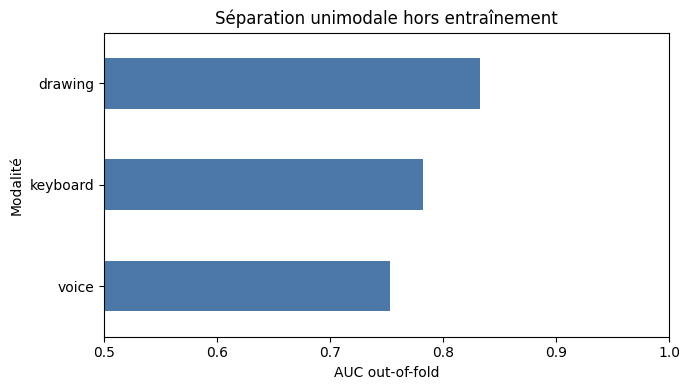

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
pool_summary.sort_values('auc').plot.barh(x='configuration', y='auc', ax=ax, legend=False, color='#4C78A8')
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('AUC out-of-fold')
ax.set_ylabel('Modalité')
ax.set_title('Séparation unimodale hors entraînement')
plt.tight_layout()

## 3. Fusion tardive sur pseudo-cohortes

La fusion associe aléatoirement des scores de même label issus de datasets différents. La répétition stabilise l'estimation, mais les individus restent artificiels.

In [13]:
fusion_results = evaluate_configurations(pools)
display(fusion_results.round(3))

,configuration,modalities,repeats,n_per_class_per_repeat,auc_mean,auc_std,balanced_accuracy_mean,balanced_accuracy_std,mean_hc_score,mean_pd_score
0,drawing+keyboard+voice,drawing+keyboard+voice,50,100,0.897,0.019,0.811,0.027,0.392,0.634
1,drawing+keyboard,drawing+keyboard,50,100,0.858,0.028,0.762,0.033,0.392,0.640
2,drawing+voice,drawing+voice,50,100,0.855,0.027,0.769,0.028,0.395,0.605
3,keyboard+voice,keyboard+voice,50,100,0.836,0.025,0.758,0.026,0.394,0.655
4,drawing,drawing,50,100,0.835,0.031,0.723,0.033,0.393,0.584
5,keyboard,keyboard,50,100,0.777,0.029,0.686,0.027,0.390,0.687
6,voice,voice,50,100,0.751,0.036,0.669,0.033,0.396,0.624


### Analyse de la fusion

La fusion complète **dessin + clavier + voix** obtient la meilleure performance moyenne, avec une AUC d'environ **0.897 ± 0.019** et une balanced accuracy moyenne de **0.811**. C'est supérieur à chaque modalité seule, ce qui suggère que les modalités apportent des informations partiellement complémentaires.

Les fusions à deux modalités sont également cohérentes : **dessin + clavier** et **dessin + voix** sont proches, autour de **0.858** et **0.855** d'AUC. La combinaison **clavier + voix** est un peu plus basse (**0.836**), ce qui reflète probablement le fait que, dans cette configuration, le dessin est la modalité unimodale la plus discriminante.

L'écart-type reste faible à modéré selon les configurations. Cela indique que le résultat ne dépend pas uniquement d'un appariement aléatoire particulier, mais il faut rappeler que ces pseudo-patients ne correspondent pas à de vrais sujets multimodaux.

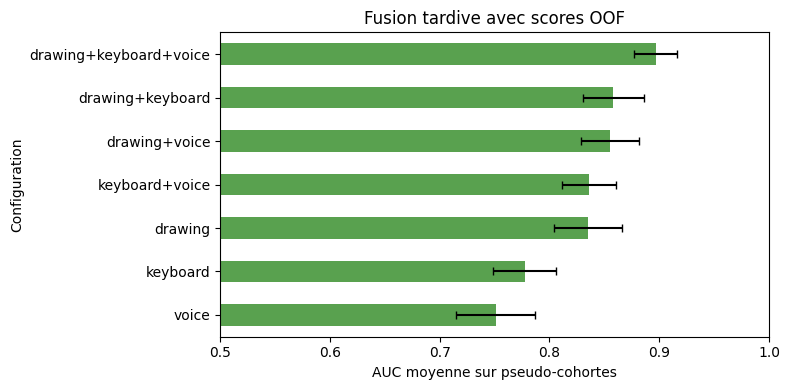

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
fusion_results.sort_values('auc_mean').plot.barh(
    x='configuration',
    y='auc_mean',
    xerr='auc_std',
    ax=ax,
    legend=False,
    color='#59A14F',
    capsize=3,
)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('AUC moyenne sur pseudo-cohortes')
ax.set_ylabel('Configuration')
ax.set_title('Fusion tardive avec scores OOF')
plt.tight_layout()

## 4. Lecture des résultats

Cette version est méthodologiquement plus propre que l'évaluation initiale, car les scores utilisés par la fusion sont **out-of-fold**. Autrement dit, chaque score est produit par un modèle entraîné sans l'observation correspondante, et les folds sont groupés par sujet quand l'identifiant est disponible.

Le résultat principal est que la fusion tardive améliore la séparation globale sur cette pseudo-cohorte : la fusion complète atteint environ **0.897 d'AUC**, contre **0.833** pour la meilleure modalité seule. Cela soutient l'intérêt d'une approche multimodale dans le cadre du projet.

La limite centrale reste la construction de la cohorte : les modalités sont appariées par label, pas par individu réel. On peut donc conclure que la fusion est cohérente et prometteuse sur des scores hors entraînement, mais pas qu'elle atteint cette performance sur de vrais patients mesurés avec les trois tests. Pour une validation définitive, il faudrait collecter un dataset commun où clavier, voix et dessin proviennent des mêmes personnes.